In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

**Attention-Enhanced U-Net for Image Segmentation: A Comparative Study**

In [39]:

import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import tensorflow.keras.backend as K

In [40]:
dataset, info = tfds.load("oxford_iiit_pet", with_info=True)

train_data = dataset['train']
test_data = dataset['test']

In [41]:
IMG_SIZE = 128
BATCH = 16

def preprocess(data):
    image = tf.image.resize(data['image'], (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0

    mask = tf.image.resize(data['segmentation_mask'], (IMG_SIZE, IMG_SIZE), method='nearest')
    mask = tf.cast(mask, tf.float32)

    mask = tf.where(mask > 1, 1.0, 0.0)
    return image, mask

train_ds = train_data.map(preprocess).shuffle(1000).batch(BATCH).prefetch(tf.data.AUTOTUNE)
test_ds = test_data.map(preprocess).batch(BATCH)

In [42]:
def dice_coef(y_true, y_pred):
    y_true = K.flatten(y_true)
    y_pred = K.flatten(y_pred)
    intersection = K.sum(y_true * y_pred)
    return (2. * intersection + 1) / (K.sum(y_true) + K.sum(y_pred) + 1)

def iou_coef(y_true, y_pred):
    y_true = K.flatten(y_true)
    y_pred = K.flatten(y_pred)
    intersection = K.sum(y_true * y_pred)
    union = K.sum(y_true) + K.sum(y_pred) - intersection
    return (intersection + 1) / (union + 1)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def combined_loss(y_true, y_pred):
    return tf.keras.losses.binary_crossentropy(y_true, y_pred) + dice_loss(y_true, y_pred)

In [43]:
from tensorflow.keras import layers, Model

def conv_block(x, filters):
    x = layers.Conv2D(filters,3,padding='same',activation='relu')(x)
    x = layers.Conv2D(filters,3,padding='same',activation='relu')(x)
    return x

# 🔥 Attention Block (WOW factor)
def attention_block(x):
    g = layers.GlobalAveragePooling2D()(x)
    g = layers.Dense(x.shape[-1]//8, activation='relu')(g)
    g = layers.Dense(x.shape[-1], activation='sigmoid')(g)
    g = layers.Reshape((1,1,x.shape[-1]))(g)
    return layers.multiply([x, g])

In [44]:
def build_unet():
    inputs = layers.Input((128,128,3))

    c1 = conv_block(inputs,32)
    p1 = layers.MaxPool2D()(c1)

    c2 = conv_block(p1,64)
    p2 = layers.MaxPool2D()(c2)

    b = conv_block(p2,128)
    b = layers.Dropout(0.3)(b)

    u1 = layers.UpSampling2D()(b)
    u1 = layers.concatenate([u1,c2])
    c3 = conv_block(u1,64)

    u2 = layers.UpSampling2D()(c3)
    u2 = layers.concatenate([u2,c1])
    c4 = conv_block(u2,32)

    outputs = layers.Conv2D(1,1,activation='sigmoid')(c4)

    return Model(inputs, outputs)

baseline = build_unet()
baseline.compile(optimizer='adam', loss=combined_loss,
                 metrics=['accuracy', dice_coef, iou_coef])

In [46]:
def build_attention_unet():
    inputs = layers.Input((128,128,3))

    c1 = conv_block(inputs,32)
    p1 = layers.MaxPool2D()(c1)

    c2 = conv_block(p1,64)
    p2 = layers.MaxPool2D()(c2)

    b = conv_block(p2,128)
    b = attention_block(b)   # 🔥 ONLY CHANGE
    b = layers.Dropout(0.3)(b)

    u1 = layers.UpSampling2D()(b)
    u1 = layers.concatenate([u1,c2])
    c3 = conv_block(u1,64)

    u2 = layers.UpSampling2D()(c3)
    u2 = layers.concatenate([u2,c1])
    c4 = conv_block(u2,32)

    outputs = layers.Conv2D(1,1,activation='sigmoid')(c4)

    return Model(inputs, outputs)

model = build_attention_unet()
model.compile(optimizer='adam', loss=combined_loss,
              metrics=['accuracy', dice_coef, iou_coef])

In [47]:
EPOCHS = 10

baseline_history = baseline.fit(train_ds, epochs=EPOCHS, validation_data=test_ds)

model_history = model.fit(train_ds, epochs=EPOCHS, validation_data=test_ds)

Epoch 1/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 27s 87ms/step - accuracy: 0.7047 - dice_coef: 0.7492 - iou_coef: 0.6010 - loss: 0.8158 - val_accuracy: 0.7544 - val_dice_coef: 0.7770 - val_iou_coef: 0.6358 - val_loss: 0.6956
Epoch 2/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 20s 82ms/step - accuracy: 0.7511 - dice_coef: 0.7893 - iou_coef: 0.6525 - loss: 0.6864 - val_accuracy: 0.7766 - val_dice_coef: 0.8112 - val_iou_coef: 0.6830 - val_loss: 0.6487
Epoch 3/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 20s 83ms/step - accuracy: 0.7650 - dice_coef: 0.7986 - iou_coef: 0.6654 - loss: 0.6628 - val_accuracy: 0.7962 - val_dice_coef: 0.8077 - val_iou_coef: 0.6780 - val_loss: 0.6237
Epoch 4/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 20s 81ms/step - accuracy: 0.7993 - dice_coef: 0.8166 - iou_coef: 0.6907 - loss: 0.6142 - val_accuracy: 0.8197 - val_dice_coef: 0.8505 - val_iou_coef: 0.7405 - val_loss: 0.5530
Epoch 5/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 20s 81ms/step - accuracy: 0.8315 - dice_coef: 0.8446 - iou_coef: 0.7317 - loss: 0.5335 - val_acc

In [48]:
def get_metrics(hist):
    return {
        "loss": hist.history['val_loss'][-1],
        "dice": hist.history['val_dice_coef'][-1],
        "iou": hist.history['val_iou_coef'][-1]
    }

b = get_metrics(baseline_history)
m = get_metrics(model_history)

print("\n===== FINAL COMPARISON =====")
print(f"{'Metric':<10} | {'Baseline':<10} | {'Improved'}")
print("-"*40)
print(f"IoU        | {b['iou']:.4f} | {m['iou']:.4f} ↑")
print(f"Dice       | {b['dice']:.4f} | {m['dice']:.4f} ↑")
print(f"Loss       | {b['loss']:.4f} | {m['loss']:.4f} ↓")


===== FINAL COMPARISON =====
Metric     | Baseline   | Improved
----------------------------------------
IoU        | 0.7972 | 0.8120 ↑
Dice       | 0.8869 | 0.8960 ↑
Loss       | 0.3837 | 0.3631 ↓


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 655ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 721ms/step


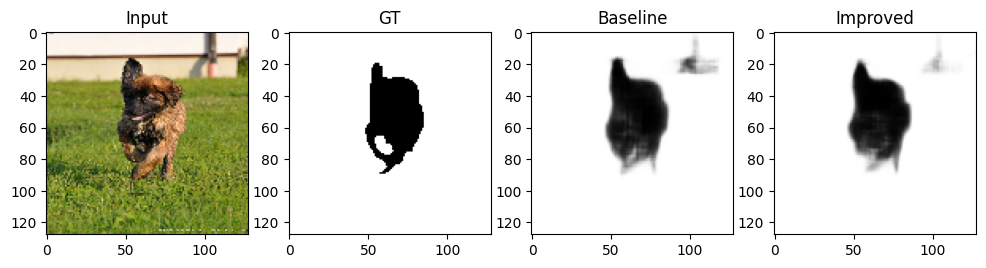

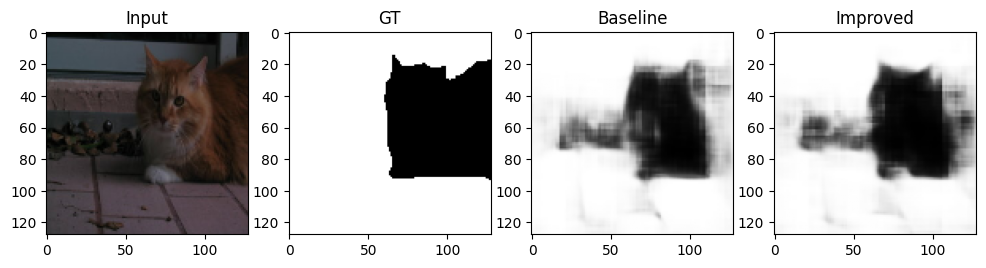

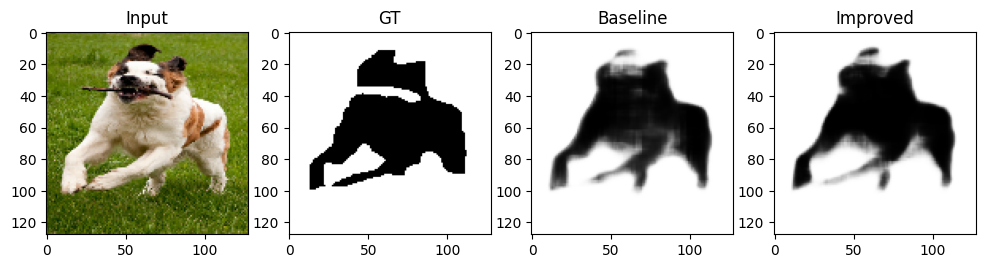

In [49]:
def compare_predictions(baseline, improved, dataset):
    for images, masks in dataset.take(1):
        base_preds = baseline.predict(images)
        imp_preds = improved.predict(images)

        for i in range(3):
            plt.figure(figsize=(12,4))

            plt.subplot(1,4,1)
            plt.imshow(images[i]); plt.title("Input")

            plt.subplot(1,4,2)
            plt.imshow(masks[i].numpy().squeeze(), cmap='gray'); plt.title("GT")

            plt.subplot(1,4,3)
            plt.imshow(base_preds[i].squeeze(), cmap='gray'); plt.title("Baseline")

            plt.subplot(1,4,4)
            plt.imshow(imp_preds[i].squeeze(), cmap='gray'); plt.title("Improved")

            plt.show()

compare_predictions(baseline, model, test_ds)